##Часть 1

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

# ── Загрузка данных ───────────────────────────────────────────────────────────
counts = pd.read_csv("raw_counts_ici_samples.tsv", sep="\t", index_col=0)
meta   = pd.read_csv("meta_responses.tsv",         sep="\t", index_col=0)
glen   = pd.read_csv("gene_length.tsv",            sep="\t", index_col=0)["median_trna_lenght"]

meta = meta[meta["0"].isin(["R", "NR"])]
shared = counts.columns.intersection(meta.index)
counts = counts[shared]
meta   = meta.loc[shared]

# ── TPM-нормализация ──────────────────────────────────────────────────────────
tpm = counts.copy().astype(float)
shared_genes = tpm.index.intersection(glen.index)
tpm.loc[shared_genes] = tpm.loc[shared_genes].div(glen[shared_genes], axis=0) * 1e3
tpm = tpm.div(tpm.sum(axis=0), axis=1) * 1e6
log_tpm = np.log2(tpm + 1)

# ── PCA ───────────────────────────────────────────────────────────────────────
PALETTE = {"R": "#E63946", "NR": "#457B9D"}

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(log_tpm.T)
ev     = pca.explained_variance_ratio_ * 100

# выбросы по z-score (порог 2.2 → ~6–8 выбросов)
z1 = np.abs((coords[:, 0] - coords[:, 0].mean()) / coords[:, 0].std())
z2 = np.abs((coords[:, 1] - coords[:, 1].mean()) / coords[:, 1].std())
is_outlier = (z1 > 0.9) | (z2 > 0.9)

# ── График ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("white")

sample_list = list(log_tpm.columns)

for label, grp in meta.groupby("0"):
    idx = [sample_list.index(s) for s in grp.index]
    ax.scatter(
        coords[idx, 0], coords[idx, 1],
        c=PALETTE[label], label=label,
        s=45, alpha=0.85,
        edgecolors="white", linewidths=0.5,
        zorder=3
    )

x_range = coords[:, 0].max() - coords[:, 0].min()
y_range = coords[:, 1].max() - coords[:, 1].min()
radius  = max(x_range, y_range) * 0.03

outlier_samples = []

for i, sample in enumerate(sample_list):
    if not is_outlier[i]:
        continue

    x, y = coords[i, 0], coords[i, 1]
    outlier_samples.append(sample)
    short = sample.split("_S")[0]

    ax.add_patch(plt.Circle(
        (x, y), radius=radius,
        fill=False, edgecolor="#FF6B35",
        linewidth=2.0, zorder=4
    ))
    ax.annotate(
        short,
        xy=(x, y),
        xytext=(x + radius * 2, y + radius * 2),
        fontsize=8, color="#FF6B35", fontweight="bold",
        arrowprops=dict(arrowstyle="-", color="#FF6B35", lw=1.2),
        zorder=5
    )

handles, labels_leg = ax.get_legend_handles_labels()
if outlier_samples:
    handles.append(mpatches.Patch(
        facecolor="none", edgecolor="#FF6B35",
        linewidth=2, label="Выброс"
    ))
    labels_leg.append("Выброс")

ax.axhline(0, color="grey", lw=0.5, ls="--", zorder=1)
ax.axvline(0, color="grey", lw=0.5, ls="--", zorder=1)
ax.set_xlabel(f"PC1  ({ev[0]:.1f}% дисперсии)", fontsize=12)
ax.set_ylabel(f"PC2  ({ev[1]:.1f}% дисперсии)", fontsize=12)
ax.set_title("PCA", fontsize=14, fontweight="bold", pad=12)
ax.grid(True, linestyle=":", alpha=0.4, zorder=0)
ax.legend(handles, labels_leg, title="Группа", framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"Выбросов: {len(outlier_samples)}")
for s in outlier_samples:
    print(f"  - {s.split('_S')[0]}")

In [ ]:
# @title
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Отбор вариабельных генов (top 1000 по дисперсии) ─────────────────────────
gene_var = log_tpm.var(axis=1)
top_genes = gene_var.nlargest(200).index
mat = log_tpm.loc[top_genes]

# ── Z-score по генам ──────────────────────────────────────────────────────────
mat_z = mat.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# ── Транспонируем: строки = образцы, столбцы = гены ──────────────────────────
mat_z_T = mat_z.T  # shape: (n_samples, n_genes)

# ── Цветовая аннотация строк (образцов) ──────────────────────────────────────
row_colors = meta["0"].map({"R": "#E63946", "NR": "#457B9D"})
row_colors = row_colors.loc[mat_z_T.index]  # выравниваем порядок

# ── обрезаем хвост в названиях образцов ──────────────────────────────────────
# перед построением clustermap
mat_z_T.index = mat_z_T.index.str.replace(r'_R1_001ReadsPerGene', '', regex=True)
row_colors.index = row_colors.index.str.replace(r'_R1_001ReadsPerGene', '', regex=True)

# ── clustermap с исправлениями ────────────────────────────────────────────────
g = sns.clustermap(
    mat_z_T,
    row_colors=row_colors,
    cmap="RdBu_r",
    center=0,
    vmin=-3, vmax=3,
    method="ward",
    metric="euclidean",
    col_cluster=False,
    row_cluster=True,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 10),
    cbar_pos=(1.02, 0.4, 0.02, 0.2),   # (x, y, width, height) — colorbar справа
    cbar_kws={"label": "Z-score"},
    dendrogram_ratio=(0.15, 0.03),      # уменьшаем col dendrogram (его нет, но ratio влияет на отступ)
    colors_ratio=0.02,
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
g.ax_heatmap.set_xlabel("Гены (top 200 по дисперсии)", fontsize=11)
g.ax_heatmap.set_ylabel("Образцы", fontsize=11)
g.fig.suptitle("Clustermap образцов", fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

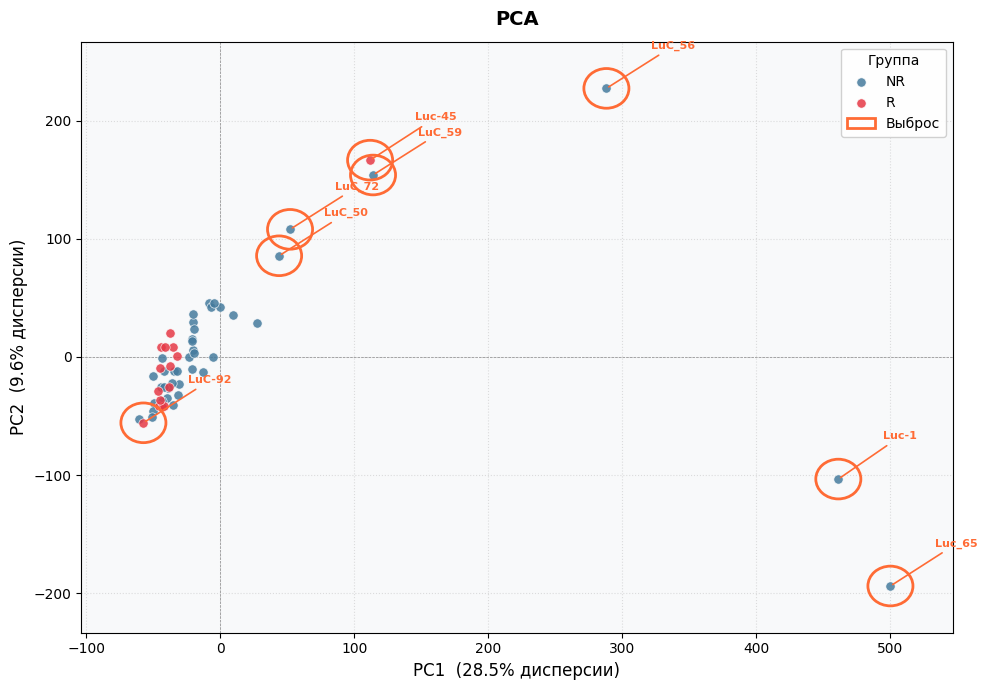

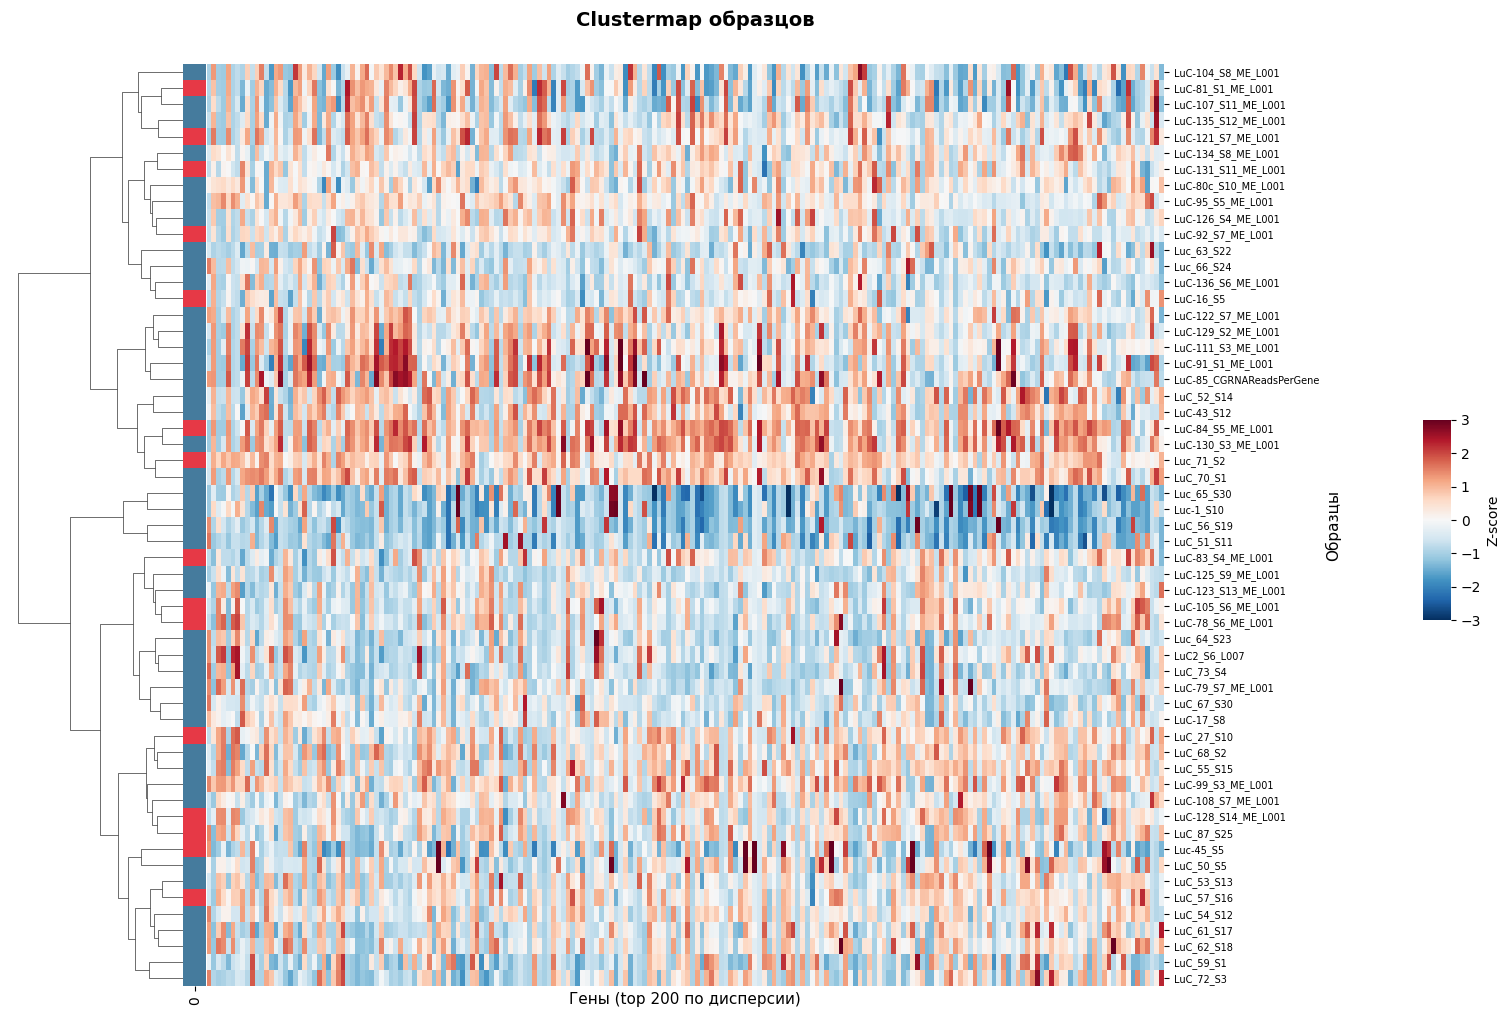

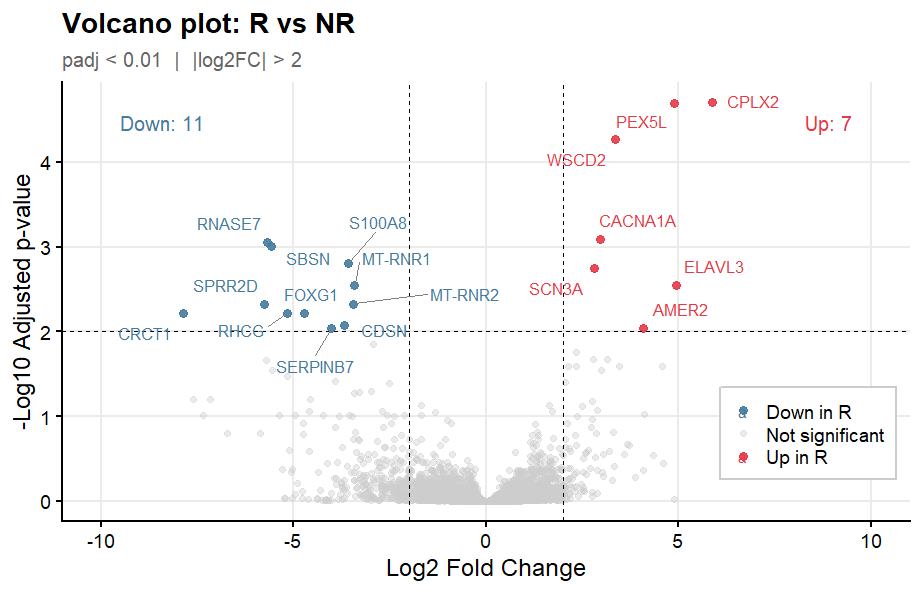

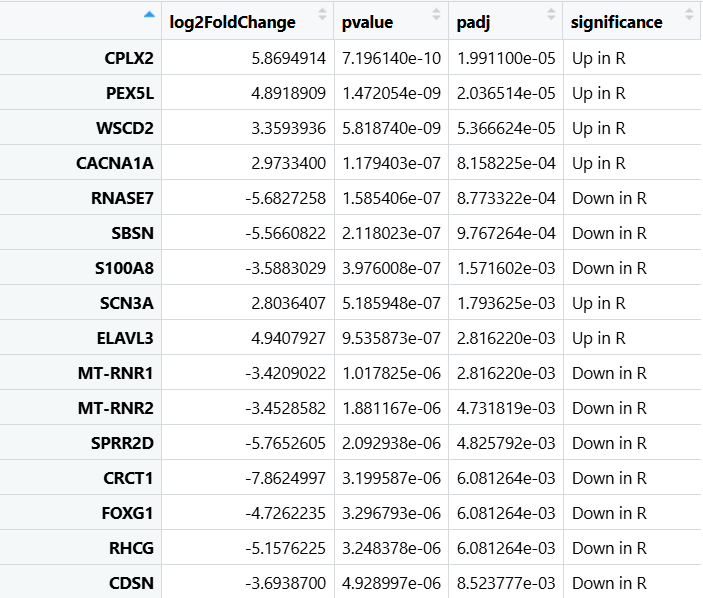

##Часть 2

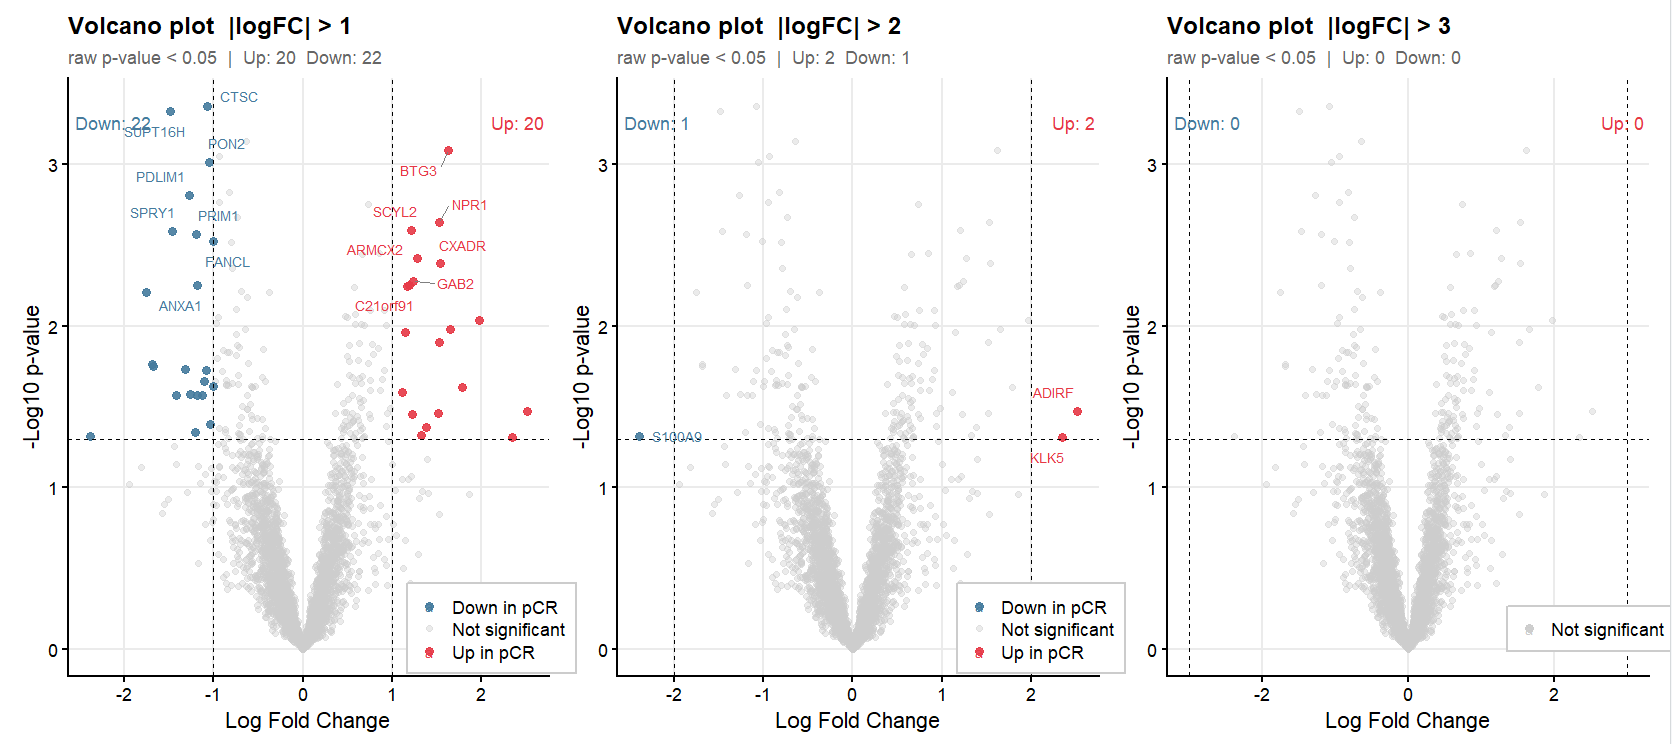

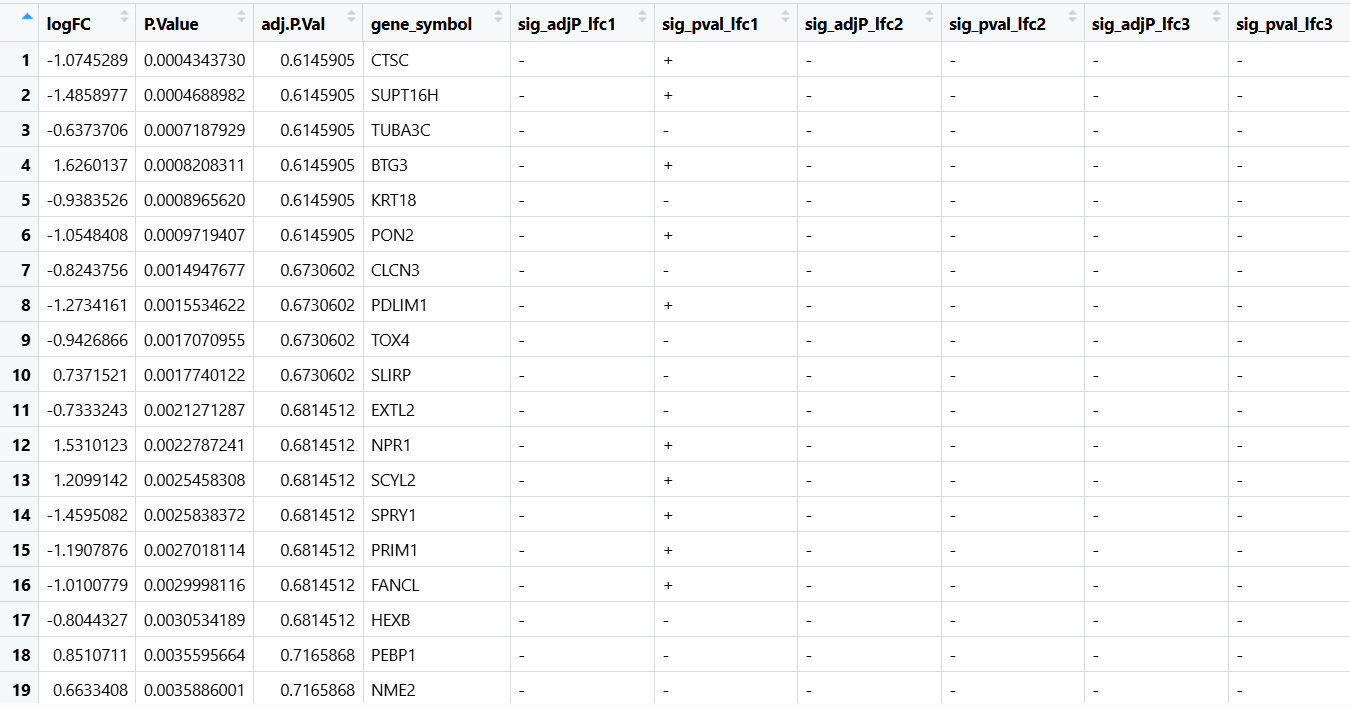